In [6]:
# Save comparison CSV
import pandas as pd
import os

comp_path = os.path.join("./xgb_matching_ratio_results/", "comparison_random_vs_kcenter_old.csv")
comp_df = pd.read_csv(comp_path)
kcenter_rows = comp_df[comp_df["source"] == 'kcenter']
random_rows = comp_df[comp_df["source"] == 'random']


import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
kc_df = pd.DataFrame(kcenter_rows).sort_values("matching_ratio")
rnd_df = pd.DataFrame(random_rows)
ratios_plot = sorted(kc_df["matching_ratio"].unique())
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric in zip(axes, ["pr_auc", "auc"]):
    ax.plot(kc_df["matching_ratio"], kc_df[metric], "o-", label="k-center (no weight)", color="C0", linewidth=2)
    rnd_agg = rnd_df.groupby("matching_ratio")[metric].agg(["mean", "std"])
    rnd_agg = rnd_agg.reindex(ratios_plot)
    means = rnd_agg["mean"].values
    stds = rnd_agg["std"].values
    ax.errorbar(ratios_plot, means, yerr=stds, fmt="s--", capsize=4, label=f"random (5 seeds)", color="C1")
    ax.set_xlabel("Matching ratio (1:k)")
    ax.set_ylabel(metric.upper().replace("_", "-"))
    ax.set_xticks(ratios_plot)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle("XGB default (no class weight): k-center vs random same-size undersample")
plt.tight_layout()
comp_plot_path = os.path.join("./random_vs_kcenter_auc_pr_auc_xgb.png")
plt.savefig(comp_plot_path, dpi=150)
plt.close()
print(f"Saved comparison plot to {comp_plot_path}")
# Plot: Recall(G-mean), specificity(G-mean), recall(MCC), specificity(MCC), recall(F1), specificity(F1) - k-center line vs random mean ± std
kc_df = pd.DataFrame(kcenter_rows).sort_values("matching_ratio")
rnd_df = pd.DataFrame(random_rows)
ratios_plot = sorted(kc_df["matching_ratio"].unique())
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, metric in zip(axes, [("recall_at_gmean", "specificity_at_gmean"), ("recall_at_mcc", "specificity_at_mcc"), ("recall_at_f1", "specificity_at_f1")]):
    ax.plot(kc_df["matching_ratio"], kc_df[metric[0]], "o-", label="recall (k-center)", color="C0", linewidth=2)
    ax.plot(kc_df["matching_ratio"], kc_df[metric[1]], "s-", label="specificity (k-center)", color="C0", linewidth=2)
    rnd_agg = rnd_df.groupby("matching_ratio")[metric[0]].agg(["mean", "std"])
    rnd_agg2 = rnd_df.groupby("matching_ratio")[metric[1]].agg(["mean", "std"])
    rnd_agg = rnd_agg.reindex(ratios_plot)
    rnd_agg2 = rnd_agg2.reindex(ratios_plot)
    means, means2 = rnd_agg["mean"].values, rnd_agg2["mean"].values
    stds, stds2 = rnd_agg["std"].values, rnd_agg2["std"].values
    ax.errorbar(ratios_plot, means, yerr=stds, fmt="o--", capsize=4, label=f"recall (random)", color="C1")
    ax.errorbar(ratios_plot, means2, yerr=stds2, fmt="s--", capsize=4, label=f"specificity (random)", color="C1")
    ax.set_xlabel("Matching ratio (1:k)")
    ax.set_ylabel(metric[0].upper().replace("_", "-"))
    ax.set_xticks(ratios_plot)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle("XGB default (no class weight): k-center vs random same-size undersample")
plt.tight_layout()
comp_plot_path = os.path.join("./random_vs_kcenter_recall_xgb.png")
plt.savefig(comp_plot_path, dpi=150)
plt.close()
print(f"Saved comparison plot to {comp_plot_path}")


Saved comparison plot to ./random_vs_kcenter_auc_pr_auc_xgb.png
Saved comparison plot to ./random_vs_kcenter_recall_xgb.png


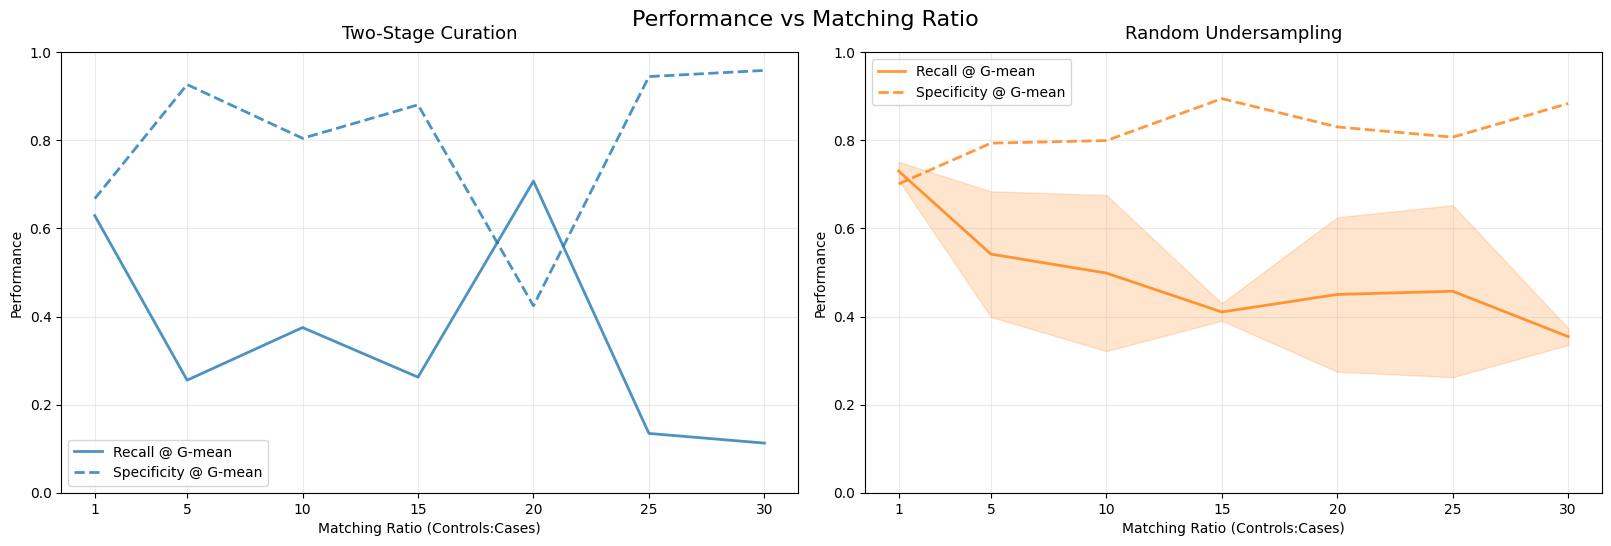

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_exp = pd.read_csv("oct_matching_ratio_results_from_existing/oct_ratio_sweep_from_existing_undersamples.csv")
df_exp2 = pd.read_csv("oct_matching_ratio_results_from_existing/random_ratio_oct_results.csv")

def agg(df, group_cols):
    agg_cols = ["auc", "pr_auc", "mcc", "recall_at_gmean", "specificity_at_gmean","recall_at_specificity_0.6","achieved_specificity_0.6"]
    out = (df.groupby(group_cols)[agg_cols]
           .agg(["mean", "std", "count"])
           .reset_index())
    # flatten
    out.columns = ["_".join([c for c in col if c]) for col in out.columns.values]
    return out

# Aggregate by ratio only (across seeds)
exp_agg = agg(df_exp, ["matching_ratio"])
exp_agg2 = agg(df_exp2, ["matching_ratio"])

def make_panel(ax, df, title, recall_metric, specificity_metric, color):
    x = df["matching_ratio"].values  # ratio values
    y_recall = df[f"{recall_metric}_mean"].values
    y_spec = df[f"{specificity_metric}_mean"].values
    
    # Plot recall and specificity vs ratio
    ax.plot(x, y_recall,  label='Recall @ G-mean', 
            color=color, linewidth=2, markersize=8, alpha=0.8)
    ax.plot(x, y_spec, label='Specificity @ G-mean', 
            color=color, linewidth=2, markersize=8, alpha=0.8, linestyle='--')
    
    # Add error bars if desired
    ax.fill_between(x, 
                     y_recall - df[f"{recall_metric}_std"].values,
                     y_recall + df[f"{recall_metric}_std"].values,
                     alpha=0.2, color=color)
    
    ax.set_title(title, fontsize=13, pad=10)
    ax.set_xlabel("Matching Ratio (Controls:Cases)")
    ax.set_ylabel("Performance")
    ax.grid(True, alpha=0.25)
    ax.legend()
    
    return ax

fig, axes = plt.subplots(1, 2, figsize=(16, 5.2), constrained_layout=True)

#make_panel(axes[0], exp_agg, "Two-Stage Curation", 'recall_at_specificity_0.6', 'achieved_specificity_0.6', 'tab:blue')
#make_panel(axes[1], exp_agg2, "Random Undersampling", 'recall_at_specificity_0.6', 'achieved_specificity_0.6', 'tab:orange')
make_panel(axes[0], exp_agg, "Two-Stage Curation", 'recall_at_gmean', 'specificity_at_gmean', 'tab:blue')
make_panel(axes[1], exp_agg2, "Random Undersampling", 'recall_at_gmean', 'specificity_at_gmean', 'tab:orange')
# Harmonize y-axis
for ax in axes:
    ax.set_ylim(0, 1)
    ax.set_xticks([1, 5, 10, 15, 20, 25, 30])

fig.suptitle("Performance vs Matching Ratio", fontsize=16, y=1.02)
plt.show()

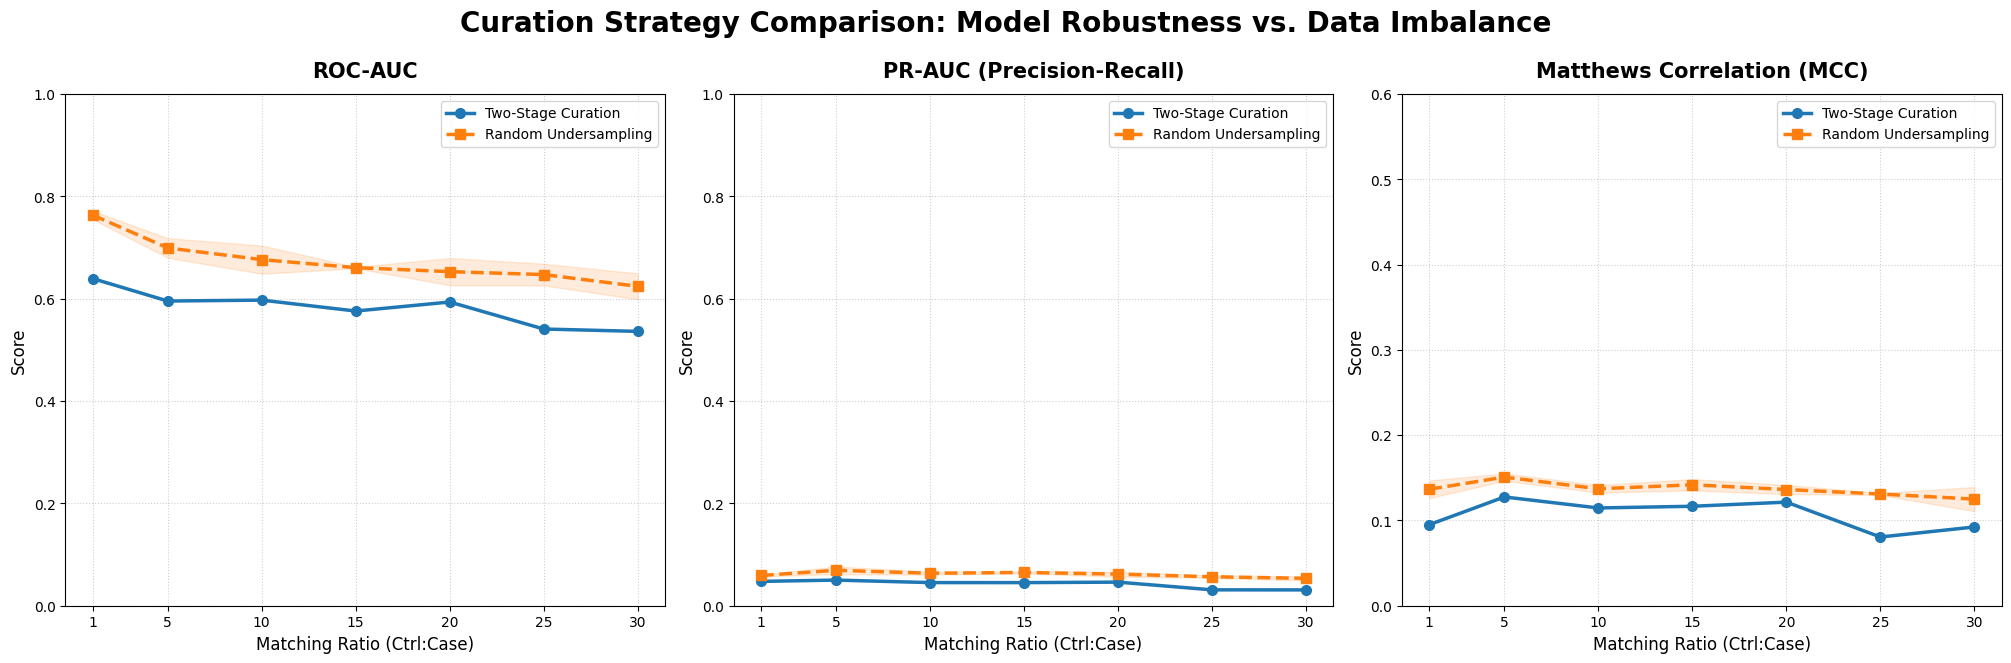

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df_exp = pd.read_csv("oct_matching_ratio_results_from_existing/oct_ratio_sweep_from_existing_undersamples.csv")
df_exp2 = pd.read_csv("oct_matching_ratio_results_from_existing/random_ratio_oct_results.csv")

def agg(df, group_cols):
    agg_cols = ["auc", "pr_auc", "mcc", "recall_at_gmean", "specificity_at_gmean"]
    out = (df.groupby(group_cols)[agg_cols]
           .agg(["mean", "std"]))
    # Flatten columns: e.g., ('auc', 'mean') -> 'auc_mean'
    out.columns = ["_".join(col).strip() for col in out.columns.values]
    return out.reset_index()

# Aggregate both datasets
exp_agg = agg(df_exp, ["matching_ratio"])
random_agg = agg(df_exp2, ["matching_ratio"])

def make_panel(ax, df_curation, df_random, metric, title):
    x_cur = df_curation["matching_ratio"].values
    y_cur = df_curation[f"{metric}_mean"].values
    std_cur = df_curation[f"{metric}_std"].values

    x_ran = df_random["matching_ratio"].values
    y_ran = df_random[f"{metric}_mean"].values
    std_ran = df_random[f"{metric}_std"].values

    # Plot Two-Stage Curation (Blue)
    ax.plot(x_cur, y_cur, marker='o', label='Two-Stage Curation', 
            color='tab:blue', linewidth=2.5, markersize=7)
    ax.fill_between(x_cur, y_cur - std_cur, y_cur + std_cur, 
                    alpha=0.15, color='tab:blue')

    # Plot Random Undersampling (Orange)
    ax.plot(x_ran, y_ran, marker='s', label='Random Undersampling', 
            color='tab:orange', linewidth=2.5, markersize=7, linestyle='--')
    ax.fill_between(x_ran, y_ran - std_ran, y_ran + std_ran, 
                    alpha=0.15, color='tab:orange')

    # Formatting
    ax.set_title(title, fontsize=15, fontweight='bold', pad=12)
    ax.set_xlabel("Matching Ratio (Ctrl:Case)", fontsize=12)
    ax.set_ylabel("Score", fontsize=12)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_xticks([1, 5, 10, 15, 20, 25, 30])
    
    # Adjust Y-limits per metric for better visibility while keeping scale
    if metric == "mcc":
        ax.set_ylim(0, 0.6) # MCC is usually lower than AUC
    else:
        ax.set_ylim(0.0, 1.0) # AUC/PR-AUC focus on the 0.5-1.0 range

    ax.legend(frameon=True, loc='best', fontsize=10)

# Create 1x3 Figure
fig, axes = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)

metrics = ["auc", "pr_auc", "mcc"]
titles = ["ROC-AUC", "PR-AUC (Precision-Recall)", "Matthews Correlation (MCC)"]

for i, metric in enumerate(metrics):
    make_panel(axes[i], exp_agg, random_agg, metric, titles[i])

fig.suptitle("Curation Strategy Comparison: Model Robustness vs. Data Imbalance", 
             fontsize=20, fontweight='bold', y=1.08)

plt.show()

In [4]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, os

df_exp=pd.read_csv("exp_random_vs_curation_medical_only_features/results/experiment_summary.csv")
df_exp2=pd.read_csv("exp_random_vs_curation_all_features_smart_seed/results/experiment_summary.csv")
df_static=pd.read_csv("two_stage_undersampled_dfs/feature_subset_comparison_results_static_pool.csv")
df_adapt=pd.read_csv("two_stage_undersampled_dfs/feature_subset_comparison_results.csv")

def agg(df, group_cols):
    agg_cols=["auc","pr_auc","best_mcc","balanced_recall_gmean","balanced_specificity_gmean","optimal_f1"]
    out=(df.groupby(group_cols)[agg_cols]
           .agg(["mean","std","count"])
           .reset_index())
    # flatten
    out.columns=["_".join([c for c in col if c]) for col in out.columns.values]
    return out

exp_agg=agg(df_exp, ["experiment","variant"])
exp_agg2=agg(df_exp2, ["experiment","variant"])
static_agg=agg(df_static, ["feature_subset","distance_dir"])
adapt_agg=agg(df_adapt, ["feature_subset","distance_dir"])

import matplotlib.pyplot as plt, numpy as np, pandas as pd, textwrap, os

def make_panel(ax, df, title, label_col):
    x=df["balanced_recall_gmean_mean"].values 
    y=df["balanced_specificity_gmean_mean"].values
    c=df["pr_auc_mean"].values
    sc=ax.scatter(x,y,c=c,s=220,alpha=0.9)
    ax.set_title(title, fontsize=13, pad=10)
    ax.set_xlabel("Recall @ Gmean-threshold")
    ax.set_ylabel("Precision @ Gmean-threshold")
    ax.grid(True, alpha=0.25)
    # annotations
    for xi, yi, lab in zip(x,y,df[label_col].astype(str).values):
        ax.annotate(lab, (xi,yi), textcoords="offset points", xytext=(6,6), fontsize=9)
    return sc

# prep labels
exp_plot=exp_agg.copy()
exp_plot["label"]=exp_plot["experiment"]+" / "+exp_plot["variant"]

exp_plot2=exp_agg2.copy()
exp_plot2["label"]=exp_plot2["experiment"]+" / "+exp_plot2["variant"]

static_plot=static_agg.copy()
static_plot["label"]=static_plot["feature_subset"]

adapt_plot=adapt_agg.copy()
adapt_plot["label"]=adapt_plot["feature_subset"]

fig, axes=plt.subplots(1,2, figsize=(18,5.2), constrained_layout=True)
sc1=make_panel(axes[0], exp_plot, "Random vs Curation (medical features for distance + prediction)", "label")
sc2=make_panel(axes[1], exp_plot2, "Random vs Curation (medical features for distance + all features forprediction)", "label")
#sc1=make_panel(axes[0], static_plot, "Curated — Static pool (M ≈ 0.5|controls|)\nFeature subset used for distances", "label")
#sc2=make_panel(axes[1], adapt_plot, "Curated — Adaptive pool\nFeature subset used for distances", "label")

# common colorbar for PR-AUC
cbar=fig.colorbar(sc1, ax=axes, location="right", shrink=0.92, pad=0.01)
cbar.set_label("Test PR-AUC", rotation=90)

# harmonize axes limits for comparability
all_x=np.concatenate([exp_plot["balanced_recall_gmean_mean"], static_plot["balanced_recall_gmean_mean"], adapt_plot["balanced_recall_gmean_mean"]])
all_y=np.concatenate([exp_plot["balanced_specificity_gmean_mean"], static_plot["balanced_specificity_gmean_mean"], adapt_plot["balanced_specificity_gmean_mean"]])
xmin=max(0, float(all_x.min())-0.03); xmax=min(1, float(all_x.max())+0.03)
ymin=max(0, float(all_y.min())-0.03); ymax=min(1, float(all_y.max())+0.03)
for ax in axes:
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

#fig.suptitle("Experiment Landscape (Recall–Precision plane; color = PR-AUC)", fontsize=16, y=1.03)


fig


ParserError: Error tokenizing data. C error: Expected 20 fields in line 14, saw 21


In [2]:
out_path="landscape_plot.png"
fig.savefig(out_path, dpi=200, bbox_inches="tight")
out_path


'landscape_plot.png'

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


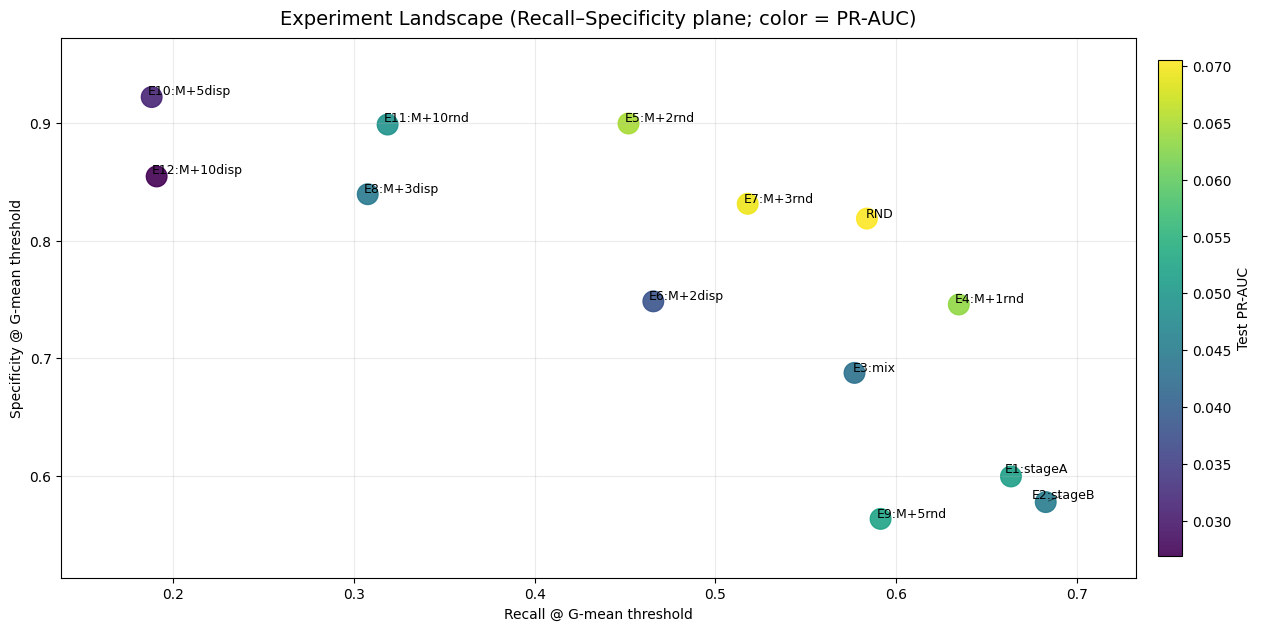

In [1]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from pathlib import Path

path = "exp_random_vs_curation_medical_only_for_prediction_smart/results/experiment_summary.csv"
lines = Path(path).read_text().splitlines()

HEADER = next(csv.reader([lines[0]]))  # 20 cols
ALT_COLUMNS = [  # 21 cols (your appended format)
    "experiment","variant","seed","n_cases","n_controls",
    "auc","pr_auc","best_mcc","recall_mcc","specificity_mcc",
    "precision_mcc",  # often blank
    "optimal_f1",
    "balanced_recall_gmean","balanced_specificity_gmean",
    "num_leaves","best_depth","best_minbucket","best_cp",
    "recall_at_specificity_0.6","achieved_specificity_0.6","threshold_specificity_0.6"
]
rows = []
for ln in lines[1:]:
    if not ln.strip():
        continue
    cols = next(csv.reader([ln]))
    if len(cols) == len(HEADER):
        rows.append(dict(zip(HEADER, cols)))
    elif len(cols) == len(ALT_COLUMNS):
        rows.append(dict(zip(ALT_COLUMNS, cols)))
    else:
        # unknown format -> skip
        continue

df_raw = pd.DataFrame(rows)

# numeric coercion
num_cols = [
    "seed","n_cases","n_controls","best_depth","best_minbucket","best_cp","num_leaves",
    "auc","pr_auc","best_mcc","recall_mcc","specificity_mcc","precision_mcc","optimal_f1",
    "balanced_recall_gmean","balanced_specificity_gmean",
]
for c in num_cols:
    if c in df_raw.columns:
        df_raw[c] = pd.to_numeric(df_raw[c], errors="coerce")

# keep only “real per-seed” rows (best_depth present)
#df = df_raw[df_raw["best_depth"].notna()].copy()
df = df_raw[df_raw["seed"].notna()]
df["seed"] = df["seed"].astype(int)

def agg(df, group_cols):
    agg_cols = ["auc","pr_auc","best_mcc","balanced_recall_gmean","balanced_specificity_gmean","optimal_f1"]
    agg_cols = [c for c in agg_cols if c in df.columns]
    out = (df.groupby(group_cols)[agg_cols]
             .agg(["mean","std","count"])
             .reset_index())
    out.columns = ["_".join([c for c in col if c]) for col in out.columns.values]
    return out

exp_agg = agg(df, ["experiment","variant"])

def make_label(exp, var):
    if exp == "random_undersample":
        return "RND"
    m = re.match(r"exp(\d+)", str(exp))
    if not m:
        return f"{exp}"
    num = int(m.group(1))
    if num <= 3:
        return f"E{num}:{var}"
    mm = re.match(r"matched_1N_plus_(\d+)N_(.*)", str(var))
    if mm:
        mult = mm.group(1)
        typ = mm.group(2)
        typ_short = "rnd" if typ == "random" else ("disp" if typ == "max_dispersed" else typ[:4])
        return f"E{num}:M+{mult}{typ_short}"
    return f"E{num}:{var}"

plot_df = exp_agg.copy()
plot_df["label"] = [make_label(e,v) for e,v in zip(plot_df["experiment"], plot_df["variant"])]

x = plot_df["balanced_recall_gmean_mean"].values
y = plot_df["balanced_specificity_gmean_mean"].values
c = plot_df["pr_auc_mean"].values
labels = plot_df["label"].astype(str).values

fig, ax = plt.subplots(figsize=(12.5, 6.2), constrained_layout=True)
sc = ax.scatter(x, y, c=c, s=220, alpha=0.9)
ax.set_title("Experiment Landscape (Recall–Specificity plane; color = PR-AUC)", fontsize=14, pad=10)
ax.set_xlabel("Recall @ G-mean threshold")
ax.set_ylabel("Specificity @ G-mean threshold")
ax.grid(True, alpha=0.25)

from adjustText import adjust_text

texts = []
for xi, yi, lab in zip(x, y, labels):
    texts.append(ax.text(xi, yi, lab, fontsize=9))

adjust_text(
    texts, ax=ax,
    expand_points=(1.2, 1.2),
    expand_text=(1.2, 1.2),
    force_points=(0.5, 0.5),
    force_text=(0.5, 0.5),
    arrowprops=dict(arrowstyle="-", lw=0.6, alpha=0.6),
)
xmin = max(0, float(np.nanmin(x)) - 0.05); xmax = min(1, float(np.nanmax(x)) + 0.05)
ymin = max(0, float(np.nanmin(y)) - 0.05); ymax = min(1, float(np.nanmax(y)) + 0.05)
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

cbar = fig.colorbar(sc, ax=ax, location="right", shrink=0.92, pad=0.02)
cbar.set_label("Test PR-AUC", rotation=90)

plt.show()
